In [1]:
# Optimized Fine-tuning of ResNet50 with Augmentation and Evaluation Pipeline

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras imports
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
root_path = '/kaggle/input/food5k-image-dataset'
train_path = os.path.join(root_path, 'training')
val_path = os.path.join(root_path, 'validation')
test_path = os.path.join(root_path, 'evaluation')

# Data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(
    val_path, target_size=(224, 224), batch_size=32, class_mode='binary')
test_generator = test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# đúng path tới file bạn vừa upload
weights_path = "/kaggle/input/ggwellplay/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"

# Khởi tạo ResNet50 không có fully-connected layer
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))

# Nạp pretrained weights
base_model.load_weights(weights_path)
print("ResNet50 weights loaded thành công!")

# Custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.25)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze initial layers, unfreeze deeper ones
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Compile model
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('best_resnet_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

print(train_generator.class_indices)
print(val_generator.class_indices)


Found 3000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
ResNet50 weights loaded thành công!
{'food': 0, 'non_food': 1}
{'food': 0, 'non_food': 1}


In [2]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)


test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

Train for 94 steps, validate for 32 steps
Epoch 1/5
93/94 [============================>.] - ETA: 6s - loss: 0.2008 - accuracy: 0.9198 
Epoch 00001: val_accuracy improved from -inf to 0.96000, saving model to best_resnet_model.h5
94/94 [==============================] - 690s 7s/step - loss: 0.1991 - accuracy: 0.9207 - val_loss: 0.1341 - val_accuracy: 0.9600
Epoch 2/5
93/94 [============================>.] - ETA: 5s - loss: 0.0461 - accuracy: 0.9848 
Epoch 00002: val_accuracy improved from 0.96000 to 0.97900, saving model to best_resnet_model.h5
94/94 [==============================] - 675s 7s/step - loss: 0.0465 - accuracy: 0.9847 - val_loss: 0.0700 - val_accuracy: 0.9790
Epoch 3/5
93/94 [============================>.] - ETA: 5s - loss: 0.0181 - accuracy: 0.9943 
Epoch 00003: val_accuracy did not improve from 0.97900
94/94 [==============================] - 673s 7s/step - loss: 0.0180 - accuracy: 0.9943 - val_loss: 0.0822 - val_accuracy: 0.9760
Epoch 4/5
93/94 [=======================

In [3]:
# Predict
predictions = (model.predict(test_generator) > 0.5).astype(int)
true_labels = test_generator.classes

              precision    recall  f1-score   support

    Non-food       0.97      0.99      0.98       500
        Food       0.99      0.97      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



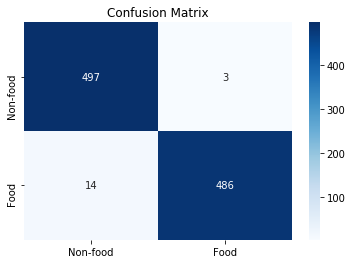

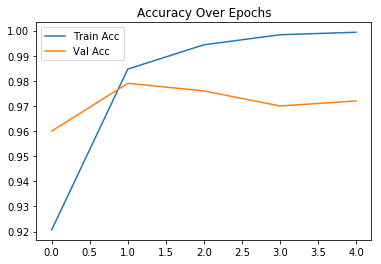

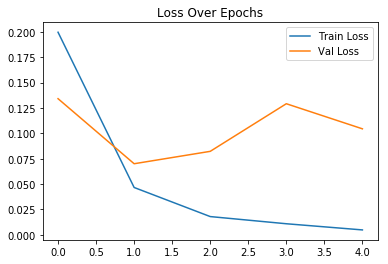

In [4]:
# Report
print(classification_report(true_labels, predictions, target_names=['Non-food', 'Food']))

# Confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-food', 'Food'], yticklabels=['Non-food', 'Food'])
plt.title('Confusion Matrix')
plt.show()

# Accuracy & loss plots
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.show()

In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import load_model

# Load model đã train
model = load_model("best_resnet_model.h5")

def predict_image(img_path):
    """
    Nhận path tới ảnh, trả về label 'Class 0' hoặc 'Class 1'
    """
    # Load ảnh và resize về 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Chuyển thành mảng numpy
    x = image.img_to_array(img)
    
    # Thêm batch dimension
    x = np.expand_dims(x, axis=0)
    
    # Preprocess ảnh
    x = preprocess_input(x)
    
    # Dự đoán
    pred = model.predict(x)
    
    # Chuyển sang label 0 hoặc 1
    label = "Non food" if pred[0][0] > 0.5 else "Food"
    confidence = pred[0][0] if pred[0][0] > 0.5 else 1 - pred[0][0]
    
    print(f"Prediction: {label}, Confidence: {confidence:.4f}")
    return label



In [6]:
# Ví dụ sử dụng
predict_image("/kaggle/input/food5k-image-dataset/validation/food/0.jpg")

Prediction: Food, Confidence: 1.0000


'Food'